# Experiment: Candidate Table Frontier at 250 m

Purpose:
- inspect the unassigned single-user frontier at 250 m,
- compare the raw full-frame table against the current strict-pruned frontier,
- surface patterns that should drive the next pruning design.

This notebook intentionally builds only the 250 m bin so the analysis stays fast enough to iterate on.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
from time import perf_counter

from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "tests").exists():
            return candidate
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import candidate_table_generation.builder as table_builder
from candidate_table_generation.pruning import prune_candidate_frontier

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 40)

DISTANCE_M = 250


## Rate meaning

`rate_active_bps` means the achieved throughput when the PHY operating point stays active for the full modeled frame.
TDMA later converts that active rate into user-specific average rate by assigning only a share of slots in the repeated window.


In [2]:
started_at = perf_counter()

engine_state = table_builder._resolve_default_single_user_engine_state()
frame_n_slots = int(engine_state.model_inputs.n_slots_win)
active_table = table_builder._enumerate_active_candidates_for_distance(
    DISTANCE_M,
    engine_state=engine_state,
)
full_frame_table = table_builder._project_active_table_to_candidate_frontier(
    active_table,
    frame_n_slots=frame_n_slots,
)
frontier_table = prune_candidate_frontier(full_frame_table)

elapsed_s = perf_counter() - started_at

build_summary = pd.DataFrame(
    [
        {"stage": "raw_active_table", "rows": len(active_table)},
        {"stage": "full_frame_projection", "rows": len(full_frame_table)},
        {"stage": "strict_pruned_frontier", "rows": len(frontier_table)},
    ]
)
build_summary["reduction_from_previous_pct"] = (
    100.0
    * (1.0 - build_summary["rows"] / build_summary["rows"].shift(1))
).round(2)
build_summary["reduction_from_previous_pct"] = build_summary["reduction_from_previous_pct"].fillna(0.0)

print(f"Built the {DISTANCE_M} m frontier in {elapsed_s:.1f} s")
display(build_summary)


Built the 250 m frontier in 51.9 s


,stage,rows,reduction_from_previous_pct
0,raw_active_table,221300,0.00
1,full_frame_projection,11065,95.00
2,strict_pruned_frontier,2584,76.65


## User-facing frontier at 100 Mbps

If one user needs `100 Mbps` average throughput, the relevant lookup result is not the whole `250 m` stored frontier.
It is the subset with `rate_active_bps >= 100e6`.

For each surviving stored row, the scheduler-facing slot demand is:
`required_slots = ceil(frame_n_slots * target_rate_bps / rate_active_bps)`

So this section shows the exact candidate points a `100 Mbps` user would carry into TDMA from the stored frontier.


In [3]:
TARGET_RATE_BPS = 100e6
TARGET_RATE_MBPS = TARGET_RATE_BPS / 1e6


def build_user_frontier_view(frontier_table, *, target_rate_bps, frame_n_slots):
    user_frontier = frontier_table[
        frontier_table["rate_active_bps"].astype(float) >= float(target_rate_bps)
    ].copy()
    if user_frontier.empty:
        return user_frontier.assign(
            required_slots=pd.Series(dtype=int),
            slot_share_pct=pd.Series(dtype=float),
            rate_active_mbps=pd.Series(dtype=float),
            power_efficiency_mbps_per_w=pd.Series(dtype=float),
        )

    user_frontier["required_slots"] = np.ceil(
        float(frame_n_slots) * float(target_rate_bps) / user_frontier["rate_active_bps"].astype(float)
    ).astype(int)
    user_frontier["slot_share_pct"] = (
        100.0 * user_frontier["required_slots"].astype(float) / float(frame_n_slots)
    )
    user_frontier["rate_active_mbps"] = user_frontier["rate_active_bps"].astype(float) / 1e6
    user_frontier["power_efficiency_mbps_per_w"] = (
        user_frontier["rate_active_mbps"] / user_frontier["p_dc_active_w"].astype(float)
    )
    return user_frontier.sort_values(
        ["required_slots", "p_dc_active_w", "n_prb", "mcs", "layers", "pa_id"],
        ascending=[True, True, True, True, True, True],
    ).reset_index(drop=True)


full_frame_target_table = full_frame_table[
    full_frame_table["rate_active_bps"].astype(float) >= TARGET_RATE_BPS
].copy()
user_frontier_table = build_user_frontier_view(
    frontier_table,
    target_rate_bps=TARGET_RATE_BPS,
    frame_n_slots=frame_n_slots,
)

user_target_summary = pd.DataFrame(
    [
        {
            "target_rate_mbps": TARGET_RATE_MBPS,
            "full_frame_rows_meeting_target": len(full_frame_target_table),
            "stored_frontier_rows_meeting_target": len(user_frontier_table),
            "best_required_slots": None if user_frontier_table.empty else int(user_frontier_table["required_slots"].min()),
            "worst_required_slots": None if user_frontier_table.empty else int(user_frontier_table["required_slots"].max()),
            "best_active_power_w": None if user_frontier_table.empty else float(user_frontier_table["p_dc_active_w"].min()),
            "worst_active_power_w": None if user_frontier_table.empty else float(user_frontier_table["p_dc_active_w"].max()),
        }
    ]
)

per_pa_user_frontier = (
    user_frontier_table.groupby("pa_id", sort=True)
    .agg(
        rows=("pa_id", "size"),
        min_required_slots=("required_slots", "min"),
        max_required_slots=("required_slots", "max"),
        min_n_prb=("n_prb", "min"),
        max_n_prb=("n_prb", "max"),
        min_rate_mbps=("rate_active_mbps", "min"),
        max_rate_mbps=("rate_active_mbps", "max"),
        min_active_power_w=("p_dc_active_w", "min"),
        max_active_power_w=("p_dc_active_w", "max"),
    )
    .reset_index()
    if not user_frontier_table.empty
    else pd.DataFrame(
        columns=[
            "pa_id",
            "rows",
            "min_required_slots",
            "max_required_slots",
            "min_n_prb",
            "max_n_prb",
            "min_rate_mbps",
            "max_rate_mbps",
            "min_active_power_w",
            "max_active_power_w",
        ]
    )
)

display(user_target_summary)
display(per_pa_user_frontier)
display(
    user_frontier_table[
        [
            "pa_id",
            "n_prb",
            "layers",
            "mcs",
            "required_slots",
            "slot_share_pct",
            "rate_active_mbps",
            "p_dc_active_w",
            "p_out_total_w",
            "power_efficiency_mbps_per_w",
        ]
    ].head(30)
)


,target_rate_mbps,full_frame_rows_meeting_target,stored_frontier_rows_meeting_target,best_required_slots,worst_required_slots,best_active_power_w,worst_active_power_w
0,100.0,4210,1609,3,20,4.219017,75.445973


,pa_id,rows,min_required_slots,max_required_slots,min_n_prb,max_n_prb,min_rate_mbps,max_rate_mbps,min_active_power_w,max_active_power_w
0,0,869,3,20,26,276,100.300723,704.221286,20.958493,75.445973
1,1,740,6,20,36,276,100.132896,359.349350,4.219017,20.185429


,pa_id,n_prb,layers,mcs,required_slots,slot_share_pct,rate_active_mbps,p_dc_active_w,p_out_total_w,power_efficiency_mbps_per_w
0,0,266,4,20,3,15.0,678.706022,71.499373,29.168330,9.492475
1,0,271,4,20,3,15.0,691.463654,72.434506,29.716521,9.546053
2,0,276,4,20,3,15.0,704.221286,73.369639,30.264712,9.598266
3,0,271,4,15,4,20.0,500.818406,44.021575,13.786068,11.376658
4,0,276,4,15,4,20.0,510.058598,44.553244,14.040384,11.448293
5,0,256,4,17,4,20.0,504.574771,44.911165,14.211590,11.234952
6,0,261,4,17,4,20.0,514.429747,45.491354,14.489115,11.308297
7,0,266,4,17,4,20.0,524.284723,46.071543,14.766640,11.379795
8,0,256,4,16,4,20.0,505.341542,46.459005,14.951977,10.877149
9,0,271,4,17,4,20.0,534.139699,46.651732,15.044165,11.449515


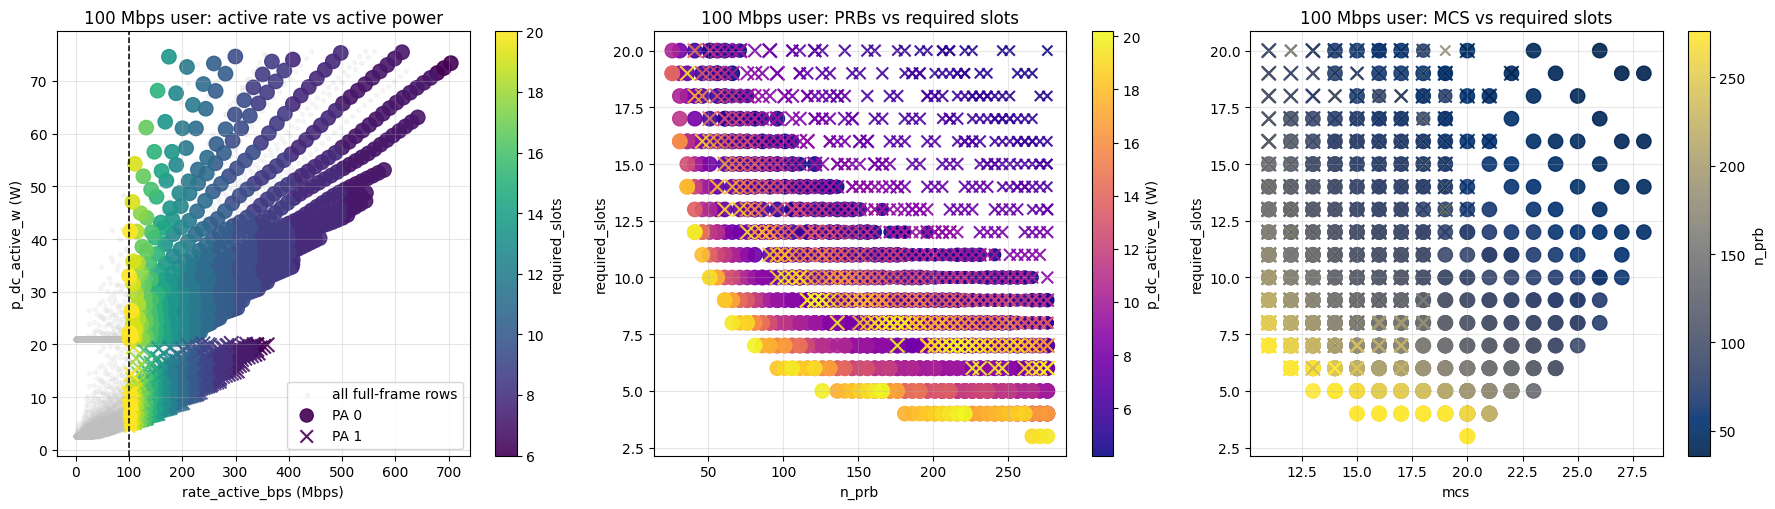

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
markers = {0: "o", 1: "x", 2: "^", 3: "s"}

axes[0].scatter(
    full_frame_table["rate_active_bps"] / 1e6,
    full_frame_table["p_dc_active_w"],
    s=8,
    alpha=0.12,
    color="0.75",
    label="all full-frame rows",
)

slot_artist = None
for pa_id, group in user_frontier_table.groupby("pa_id", sort=True):
    slot_artist = axes[0].scatter(
        group["rate_active_mbps"],
        group["p_dc_active_w"],
        c=group["required_slots"],
        cmap="viridis",
        s=35 + 18 * group["layers"],
        alpha=0.9,
        marker=markers.get(int(pa_id), "o"),
        label=f"PA {int(pa_id)}",
    )

axes[0].axvline(TARGET_RATE_MBPS, color="black", linestyle="--", linewidth=1.1)
axes[0].set_title("100 Mbps user: active rate vs active power")
axes[0].set_xlabel("rate_active_bps (Mbps)")
axes[0].set_ylabel("p_dc_active_w (W)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)
if slot_artist is not None:
    fig.colorbar(slot_artist, ax=axes[0], label="required_slots")

power_artist = None
for pa_id, group in user_frontier_table.groupby("pa_id", sort=True):
    power_artist = axes[1].scatter(
        group["n_prb"],
        group["required_slots"],
        c=group["p_dc_active_w"],
        cmap="plasma",
        s=35 + 18 * group["layers"],
        alpha=0.9,
        marker=markers.get(int(pa_id), "o"),
        label=f"PA {int(pa_id)}",
    )

axes[1].set_title("100 Mbps user: PRBs vs required slots")
axes[1].set_xlabel("n_prb")
axes[1].set_ylabel("required_slots")
axes[1].grid(True, alpha=0.3)
if power_artist is not None:
    fig.colorbar(power_artist, ax=axes[1], label="p_dc_active_w (W)")

prb_artist = None
for pa_id, group in user_frontier_table.groupby("pa_id", sort=True):
    prb_artist = axes[2].scatter(
        group["mcs"],
        group["required_slots"],
        c=group["n_prb"],
        cmap="cividis",
        s=35 + 18 * group["layers"],
        alpha=0.9,
        marker=markers.get(int(pa_id), "o"),
        label=f"PA {int(pa_id)}",
    )

axes[2].set_title("100 Mbps user: MCS vs required slots")
axes[2].set_xlabel("mcs")
axes[2].set_ylabel("required_slots")
axes[2].grid(True, alpha=0.3)
if prb_artist is not None:
    fig.colorbar(prb_artist, ax=axes[2], label="n_prb")

plt.tight_layout()
plt.show()


## Slot-domain diagnostics

The raw active table still spans many `n_slots_on` values.
The stored candidate table removes that axis completely by keeping only `n_slots_on == frame_n_slots`, so the first question is how much structure lives in the slot dimension before projection.


In [5]:
slot_summary = (
    active_table.groupby("n_slots_on", sort=True)
    .agg(
        rows=("n_slots_on", "size"),
        pa_families=("pa_id", "nunique"),
        min_n_prb=("n_prb", "min"),
        max_n_prb=("n_prb", "max"),
        min_rate_mbps=("rate_ach_bps", lambda values: float(values.min()) / 1e6),
        max_rate_mbps=("rate_ach_bps", lambda values: float(values.max()) / 1e6),
        min_active_power_w=("p_dc_avg_total_w", "min"),
        max_active_power_w=("p_dc_avg_total_w", "max"),
    )
    .reset_index()
)
slot_summary["slot_share_pct"] = (
    100.0 * slot_summary["n_slots_on"].astype(float) / float(frame_n_slots)
).round(1)
slot_summary = slot_summary[
    [
        "n_slots_on",
        "slot_share_pct",
        "rows",
        "pa_families",
        "min_n_prb",
        "max_n_prb",
        "min_rate_mbps",
        "max_rate_mbps",
        "min_active_power_w",
        "max_active_power_w",
    ]
]

display(slot_summary)


,n_slots_on,slot_share_pct,rows,pa_families,min_n_prb,max_n_prb,min_rate_mbps,max_rate_mbps,min_active_power_w,max_active_power_w
0,1,5.0,11065,2,1,276,0.002250,35.211064,1.729934,18.379451
1,2,10.0,11065,2,1,276,0.004500,70.422129,1.773869,21.398902
2,3,15.0,11065,2,1,276,0.006751,105.633193,1.817803,24.418353
3,4,20.0,11065,2,1,276,0.009001,140.844257,1.861738,27.437804
4,5,25.0,11065,2,1,276,0.011251,176.055322,1.905672,30.457255
5,6,30.0,11065,2,1,276,0.013501,211.266386,1.949606,33.476706
6,7,35.0,11065,2,1,276,0.015752,246.477450,1.993541,36.496157
7,8,40.0,11065,2,1,276,0.018002,281.688515,2.037475,39.515608
8,9,45.0,11065,2,1,276,0.020252,316.899579,2.081410,42.535058
9,10,50.0,11065,2,1,276,0.022502,352.110643,2.125344,45.554509


C:\Users\henry\AppData\Local\Temp\ipykernel_45272\1357434365.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


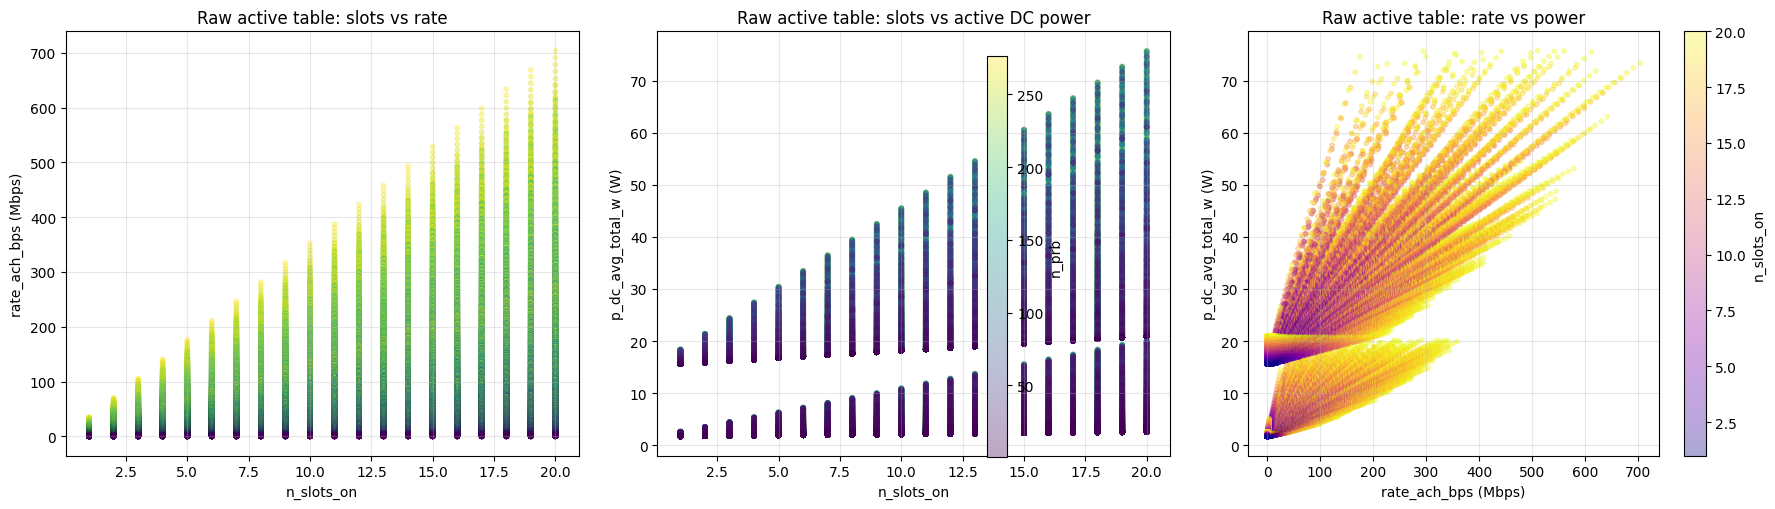

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

prb_artist = axes[0].scatter(
    active_table["n_slots_on"],
    active_table["rate_ach_bps"] / 1e6,
    c=active_table["n_prb"],
    s=10,
    alpha=0.35,
    cmap="viridis",
)
axes[0].set_title("Raw active table: slots vs rate")
axes[0].set_xlabel("n_slots_on")
axes[0].set_ylabel("rate_ach_bps (Mbps)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    active_table["n_slots_on"],
    active_table["p_dc_avg_total_w"],
    c=active_table["n_prb"],
    s=10,
    alpha=0.35,
    cmap="viridis",
)
axes[1].set_title("Raw active table: slots vs active DC power")
axes[1].set_xlabel("n_slots_on")
axes[1].set_ylabel("p_dc_avg_total_w (W)")
axes[1].grid(True, alpha=0.3)

slot_artist = axes[2].scatter(
    active_table["rate_ach_bps"] / 1e6,
    active_table["p_dc_avg_total_w"],
    c=active_table["n_slots_on"],
    s=10,
    alpha=0.35,
    cmap="plasma",
)
axes[2].set_title("Raw active table: rate vs power")
axes[2].set_xlabel("rate_ach_bps (Mbps)")
axes[2].set_ylabel("p_dc_avg_total_w (W)")
axes[2].grid(True, alpha=0.3)

fig.colorbar(prb_artist, ax=axes[:2].tolist(), label="n_prb")
fig.colorbar(slot_artist, ax=axes[2], label="n_slots_on")
plt.tight_layout()
plt.show()


## Full-frame pruning story

The stored table only sees `full_frame_table`, and the current strict dominance rule is applied within each `pa_id`:
- lower or equal `n_prb`
- lower or equal `p_dc_active_w`
- higher or equal `rate_active_bps`
- at least one strict improvement

The cells below reconstruct that decision on the pre-pruned full-frame table so the kept and dominated rows can be inspected directly.


In [7]:
DOMINANCE_TOL = 1e-12


def frontier_row_dominates(left_row, right_row):
    return (
        int(left_row["n_prb"]) <= int(right_row["n_prb"])
        and float(left_row["p_dc_active_w"]) <= float(right_row["p_dc_active_w"]) + DOMINANCE_TOL
        and float(left_row["rate_active_bps"]) >= float(right_row["rate_active_bps"]) - DOMINANCE_TOL
        and (
            int(left_row["n_prb"]) < int(right_row["n_prb"])
            or float(left_row["p_dc_active_w"]) < float(right_row["p_dc_active_w"]) - DOMINANCE_TOL
            or float(left_row["rate_active_bps"]) > float(right_row["rate_active_bps"]) + DOMINANCE_TOL
        )
    )


def annotate_pruning_roles(full_frame_candidate_table):
    ranked_rows = (
        full_frame_candidate_table.reset_index(drop=False)
        .rename(columns={"index": "row_id"})
        .sort_values(
            ["pa_id", "n_prb", "p_dc_active_w", "rate_active_bps", "mcs", "layers"],
            ascending=[True, True, True, False, True, True],
        )
        .reset_index(drop=True)
    )

    kept_rows_by_pa = {}
    row_roles = {}
    for row in ranked_rows.to_dict("records"):
        pa_id = int(row["pa_id"])
        kept_rows_for_pa = kept_rows_by_pa.setdefault(pa_id, [])
        if any(frontier_row_dominates(kept_row, row) for kept_row in kept_rows_for_pa):
            row_roles[int(row["row_id"])] = "dominated"
            continue

        kept_rows_for_pa.append(row)
        row_roles[int(row["row_id"])] = "kept"

    return (
        full_frame_candidate_table.reset_index(drop=False)
        .assign(pruning_role=lambda table: table["index"].map(row_roles))
        .drop(columns="index")
    )


full_frame_with_roles = annotate_pruning_roles(full_frame_table)

dominance_summary = pd.DataFrame(
    [
        {
            "rows_before_pruning": len(full_frame_with_roles),
            "rows_after_pruning": int(full_frame_with_roles["pruning_role"].eq("kept").sum()),
            "dominated_rows": int(full_frame_with_roles["pruning_role"].eq("dominated").sum()),
        }
    ]
)
dominance_summary["reduction_pct"] = (
    100.0
    * dominance_summary["dominated_rows"].astype(float)
    / dominance_summary["rows_before_pruning"].astype(float)
).round(2)

per_pa_dominance_summary = (
    full_frame_with_roles.groupby(["pa_id", "pruning_role"], sort=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
if "kept" not in per_pa_dominance_summary.columns:
    per_pa_dominance_summary["kept"] = 0
if "dominated" not in per_pa_dominance_summary.columns:
    per_pa_dominance_summary["dominated"] = 0
per_pa_dominance_summary["rows_before_pruning"] = (
    per_pa_dominance_summary["kept"] + per_pa_dominance_summary["dominated"]
)
per_pa_dominance_summary["reduction_pct"] = (
    100.0
    * per_pa_dominance_summary["dominated"].astype(float)
    / per_pa_dominance_summary["rows_before_pruning"].astype(float)
).round(2)
per_pa_dominance_summary = per_pa_dominance_summary[
    ["pa_id", "rows_before_pruning", "kept", "dominated", "reduction_pct"]
]

bucket_pruning_summary = (
    full_frame_with_roles.groupby(["pa_id", "n_prb"], sort=True)
    .agg(
        rows_before=("pa_id", "size"),
        rows_after=("pruning_role", lambda values: int(values.eq("kept").sum())),
        dominated_rows=("pruning_role", lambda values: int(values.eq("dominated").sum())),
        min_rate_mbps=("rate_active_bps", lambda values: float(values.min()) / 1e6),
        max_rate_mbps=("rate_active_bps", lambda values: float(values.max()) / 1e6),
        min_power_w=("p_dc_active_w", "min"),
        max_power_w=("p_dc_active_w", "max"),
    )
    .reset_index()
    .sort_values(["rows_before", "dominated_rows", "pa_id", "n_prb"], ascending=[False, False, True, True])
    .reset_index(drop=True)
)

display(dominance_summary)
display(per_pa_dominance_summary)
display(bucket_pruning_summary.head(20))


,rows_before_pruning,rows_after_pruning,dominated_rows,reduction_pct
0,11065,2584,8481,76.65


pruning_role,pa_id,rows_before_pruning,kept,dominated,reduction_pct
0,0,6033,925,5108,84.67
1,1,5032,1659,3373,67.03


,pa_id,n_prb,rows_before,rows_after,dominated_rows,min_rate_mbps,max_rate_mbps,min_power_w,max_power_w
0,0,1,116,1,115,0.045005,4.266010,20.958493,20.958493
1,0,6,116,4,112,0.270029,25.596058,20.958493,26.499134
2,0,11,116,7,109,0.495053,46.926106,20.958493,34.641947
3,0,16,116,8,108,0.720077,68.256154,20.958493,41.716613
4,0,21,116,9,107,0.945101,89.586202,20.958493,48.338137
5,1,1,116,9,107,0.045005,4.266010,2.564688,5.091611
6,0,26,116,10,106,1.170125,110.916250,20.958493,54.275707
7,0,31,116,11,105,1.395149,132.246298,20.958493,61.147441
8,0,36,116,11,105,1.620173,153.576346,20.958493,68.149157
9,0,41,116,12,104,1.845197,174.906394,20.958493,74.587066


C:\Users\henry\AppData\Local\Temp\ipykernel_45272\2932325759.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


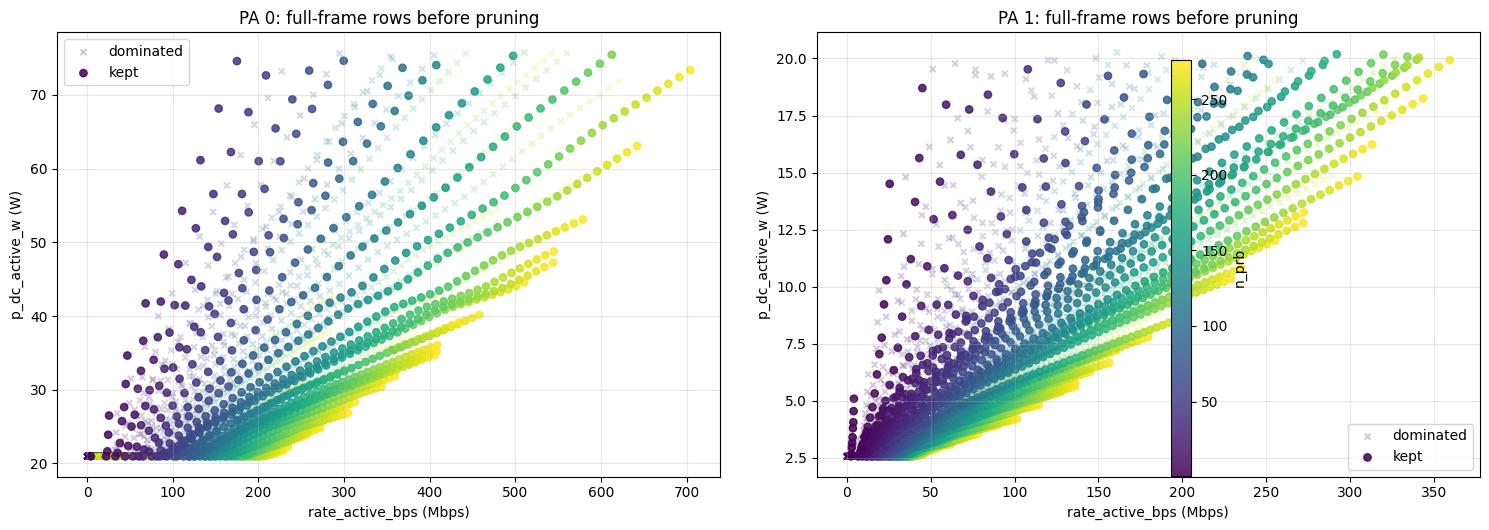

In [8]:
pa_ids = sorted(full_frame_with_roles["pa_id"].unique())
fig, axes = plt.subplots(1, len(pa_ids), figsize=(7.5 * len(pa_ids), 5.4), squeeze=False)
kept_artist = None

for ax, pa_id in zip(axes[0], pa_ids):
    pa_rows = full_frame_with_roles[full_frame_with_roles["pa_id"].eq(pa_id)].copy()
    dominated_rows = pa_rows[pa_rows["pruning_role"].eq("dominated")]
    kept_rows = pa_rows[pa_rows["pruning_role"].eq("kept")]

    if not dominated_rows.empty:
        ax.scatter(
            dominated_rows["rate_active_bps"] / 1e6,
            dominated_rows["p_dc_active_w"],
            c=dominated_rows["n_prb"],
            cmap="viridis",
            s=18,
            alpha=0.22,
            marker="x",
            label="dominated",
        )
    if not kept_rows.empty:
        kept_artist = ax.scatter(
            kept_rows["rate_active_bps"] / 1e6,
            kept_rows["p_dc_active_w"],
            c=kept_rows["n_prb"],
            cmap="viridis",
            s=28,
            alpha=0.85,
            marker="o",
            label="kept",
        )

    ax.set_title(f"PA {int(pa_id)}: full-frame rows before pruning")
    ax.set_xlabel("rate_active_bps (Mbps)")
    ax.set_ylabel("p_dc_active_w (W)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)

if kept_artist is not None:
    fig.colorbar(kept_artist, ax=axes.ravel().tolist(), label="n_prb")
plt.tight_layout()
plt.show()


,pruning_role,pa_id,n_prb,layers,mcs,rate_active_mbps,p_dc_active_w,p_out_total_w
0,kept,0,1,4,28,4.266010,20.958493,0.786304
1,dominated,0,1,4,27,4.094976,20.958493,0.609028
2,dominated,0,1,4,26,3.928474,20.958493,0.476790
3,dominated,0,1,4,25,3.698995,20.958493,0.398474
4,dominated,0,1,4,24,3.473971,20.958493,0.299070
5,dominated,0,1,4,23,3.235507,20.958493,0.253402
6,dominated,0,1,3,28,3.199507,20.958493,0.442296
7,dominated,0,1,3,27,3.071232,20.958493,0.342578
8,dominated,0,1,4,22,2.996966,20.958493,0.196998
9,dominated,0,1,3,26,2.946355,20.958493,0.268195


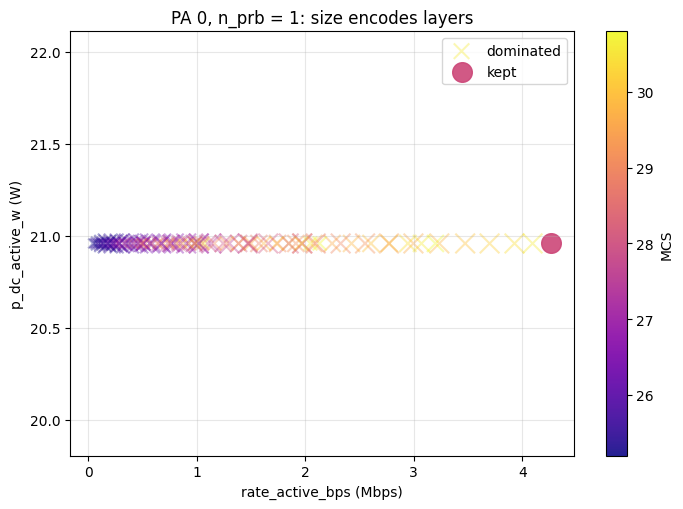

In [9]:
focus_bucket = bucket_pruning_summary.iloc[0]
focus_pa_id = int(focus_bucket["pa_id"])
focus_n_prb = int(focus_bucket["n_prb"])
focus_rows = (
    full_frame_with_roles[
        full_frame_with_roles["pa_id"].eq(focus_pa_id)
        & full_frame_with_roles["n_prb"].eq(focus_n_prb)
    ]
    .sort_values(["p_dc_active_w", "rate_active_bps", "mcs", "layers"], ascending=[True, False, True, True])
    .reset_index(drop=True)
)

focus_view = focus_rows.assign(
    rate_active_mbps=lambda table: table["rate_active_bps"] / 1e6,
)[
    [
        "pruning_role",
        "pa_id",
        "n_prb",
        "layers",
        "mcs",
        "rate_active_mbps",
        "p_dc_active_w",
        "p_out_total_w",
    ]
]

display(focus_view.head(30))

fig, ax = plt.subplots(figsize=(7.2, 5.2))
focus_artist = None
for role, marker, alpha in [("dominated", "x", 0.35), ("kept", "o", 0.9)]:
    subset = focus_rows[focus_rows["pruning_role"].eq(role)]
    if subset.empty:
        continue
    focus_artist = ax.scatter(
        subset["rate_active_bps"] / 1e6,
        subset["p_dc_active_w"],
        c=subset["mcs"],
        s=50 * subset["layers"],
        cmap="plasma",
        alpha=alpha,
        marker=marker,
        label=role,
    )

ax.set_title(f"PA {focus_pa_id}, n_prb = {focus_n_prb}: size encodes layers")
ax.set_xlabel("rate_active_bps (Mbps)")
ax.set_ylabel("p_dc_active_w (W)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
if focus_artist is not None:
    fig.colorbar(focus_artist, ax=ax, label="MCS")
plt.tight_layout()
plt.show()


## Stored frontier shape after pruning

The first table below summarizes how much structure is still left after the current same-PA strict-pruning rule.
The compaction check then measures how many rows still survive inside each `(pa_id, n_prb)` bucket, which is the next place to look for a stronger pruning rule.


In [10]:
frontier_shape = pd.DataFrame(
    [
        {
            "rows": len(frontier_table),
            "unique_pa_id": frontier_table["pa_id"].nunique(),
            "unique_n_prb": frontier_table["n_prb"].nunique(),
            "unique_layers": frontier_table["layers"].nunique(),
            "unique_mcs": frontier_table["mcs"].nunique(),
            "min_rate_active_bps": frontier_table["rate_active_bps"].min(),
            "max_rate_active_bps": frontier_table["rate_active_bps"].max(),
            "min_p_dc_active_w": frontier_table["p_dc_active_w"].min(),
            "max_p_dc_active_w": frontier_table["p_dc_active_w"].max(),
        }
    ]
)

per_pa_summary = (
    frontier_table.groupby("pa_id")
    .agg(
        rows=("pa_id", "size"),
        min_n_prb=("n_prb", "min"),
        max_n_prb=("n_prb", "max"),
        min_rate_active_bps=("rate_active_bps", "min"),
        max_rate_active_bps=("rate_active_bps", "max"),
        min_p_dc_active_w=("p_dc_active_w", "min"),
        max_p_dc_active_w=("p_dc_active_w", "max"),
    )
    .reset_index()
)

prb_bucket_sizes = (
    frontier_table.groupby(["pa_id", "n_prb"], sort=True)
    .size()
    .reset_index(name="rows_in_pa_prb_bucket")
)

prb_bucket_summary = pd.DataFrame(
    [
        {
            "rows_in_frontier": len(frontier_table),
            "unique_pa_prb_pairs": len(prb_bucket_sizes),
            "rows_beyond_one_per_pa_prb": len(frontier_table) - len(prb_bucket_sizes),
            "max_rows_in_one_pa_prb_bucket": int(prb_bucket_sizes["rows_in_pa_prb_bucket"].max()),
        }
    ]
)

largest_prb_buckets = prb_bucket_sizes.sort_values(
    ["rows_in_pa_prb_bucket", "pa_id", "n_prb"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(frontier_shape)
display(per_pa_summary)
display(prb_bucket_summary)
display(largest_prb_buckets.head(20))


,rows,unique_pa_id,unique_n_prb,unique_layers,unique_mcs,min_rate_active_bps,max_rate_active_bps,min_p_dc_active_w,max_p_dc_active_w
0,2584,2,56,4,22,2551526.4,704221286.4,2.564688,75.445973


,pa_id,rows,min_n_prb,max_n_prb,min_rate_active_bps,max_rate_active_bps,min_p_dc_active_w,max_p_dc_active_w
0,0,925,1,276,4266009.6,704221286.4,20.958493,75.445973
1,1,1659,1,276,2551526.4,359349350.4,2.564688,20.185429


,rows_in_frontier,unique_pa_prb_pairs,rows_beyond_one_per_pa_prb,max_rows_in_one_pa_prb_bucket
0,2584,112,2472,35


,pa_id,n_prb,rows_in_pa_prb_bucket
0,1,36,35
1,1,41,35
2,1,46,35
3,1,51,35
4,1,56,35
5,1,61,35
6,1,31,34
7,1,76,34
8,1,66,33
9,1,71,33


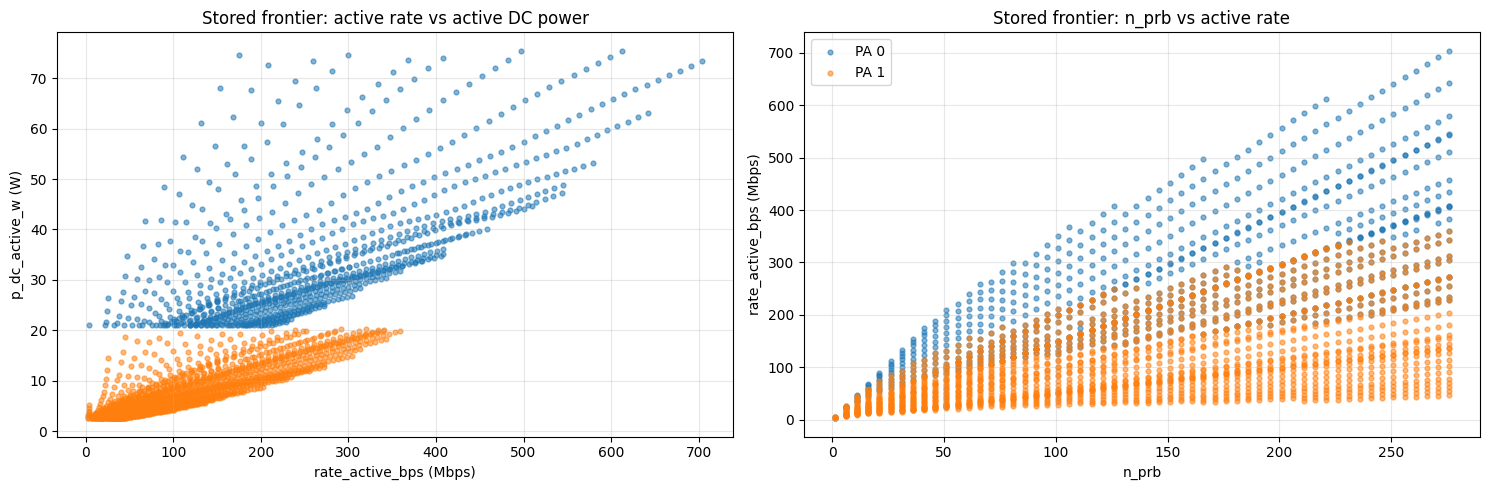

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for pa_id, group in frontier_table.groupby("pa_id", sort=True):
    label = f"PA {int(pa_id)}"
    axes[0].scatter(
        group["rate_active_bps"] / 1e6,
        group["p_dc_active_w"],
        s=12,
        alpha=0.55,
        label=label,
    )
    axes[1].scatter(
        group["n_prb"],
        group["rate_active_bps"] / 1e6,
        s=12,
        alpha=0.55,
        label=label,
    )

axes[0].set_title("Stored frontier: active rate vs active DC power")
axes[0].set_xlabel("rate_active_bps (Mbps)")
axes[0].set_ylabel("p_dc_active_w (W)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Stored frontier: n_prb vs active rate")
axes[1].set_xlabel("n_prb")
axes[1].set_ylabel("rate_active_bps (Mbps)")
axes[1].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="best")
plt.tight_layout()
plt.show()


In [12]:
frontier_table.sort_values(
    ["pa_id", "p_dc_active_w", "n_prb", "rate_active_bps"],
    ascending=[True, True, True, False],
).groupby("pa_id").head(15)


,pa_id,n_prb,layers,mcs,rate_active_bps,p_dc_active_w,p_out_total_w
0,0,1,4,28,4266009.6,20.958493,0.786304
1,0,6,4,25,22193971.2,20.958493,2.311086
5,0,11,4,22,32966630.4,20.958493,2.088151
12,0,16,4,21,44352307.2,20.958493,2.284739
20,0,21,4,20,53582054.4,20.958493,2.306971
29,0,26,4,19,60489062.4,20.958493,2.303796
39,0,31,4,18,65007744.0,20.958493,2.126324
50,0,36,4,18,75492864.0,20.958493,2.468819
61,0,41,4,16,80933606.4,20.958493,2.396696
73,0,46,4,15,85009766.4,20.958493,2.341830


## Next checks

- Check whether the densest `(pa_id, n_prb)` buckets can be trimmed further using only `rate_active_bps` and `p_dc_active_w` without changing the scheduler-facing story.
- Test whether a stronger within-bucket rule should also condition on `layers` or `mcs`, or whether those are already just labels on the same rate-power tradeoff.
- Compare 250 m against one near bin and one far bin to see whether the same slot-domain and dense-bucket patterns persist.
